<a href="https://colab.research.google.com/github/Maxxx-VS/IMA_SibADI/blob/main/%D0%97%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D0%B5_2_2_tc(Me).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Зависимость температуры охлаждающей жидкости (tc) от крутящего момента (Me).

In [7]:
!pip install --upgrade patsy statsmodels

In [9]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [10]:
# Загрузка данных из Excel и конвертация в CSV
file_name = '/content/multiregress042020.xlsx'
df = pd.read_excel(file_name, header=1)
csv_file_name = 'multiregress042020.csv'
df.to_csv(csv_file_name, index=False, encoding='utf-8-sig')


# Создаю переменные
X_data = df['Me']
Y_data = df['tc']

# Проверка перых 3 строк
print(df.head(3))

   i    ne   Me    tc      ge    CO2     NOx
0  1  1200  140  80.7  233.16   5.88  665.25
1  2  1200  210  82.8  225.23   8.67  900.50
2  3  1200  252  83.2  232.83  10.58  957.19


In [11]:
# SciPy
slope, intercept, r_value, p_value, std_err = stats.linregress(X_data, Y_data)

print(f"Уравнение регрессии: tc = {intercept:.4f} + {slope:.4f} * Me")
print(f"Коэффициент корреляции (R): {r_value:.4f}")
print(f"Коэффициент детерминации (R^2): {r_value**2:.4f}")
print(f"P-значение: {p_value:.4e} (Если < 0.05, модель статистически значима)")

Me_forecast = 200 # например Me = 200 Нм
tc_forecast = intercept + slope * Me_forecast
print(f"\nТочечный прогноз: при крутящем моменте {Me_forecast} Нм температура составит {tc_forecast:.2f} град. С\n")


Уравнение регрессии: tc = 79.3802 + 0.0175 * Me
Коэффициент корреляции (R): 0.9180
Коэффициент детерминации (R^2): 0.8428
P-значение: 1.7549e-09 (Если < 0.05, модель статистически значима)

Точечный прогноз: при крутящем моменте 200 Нм температура составит 82.89 град. С



                            OLS Regression Results                            
Dep. Variable:                     tc   R-squared:                       0.843
Model:                            OLS   Adj. R-squared:                  0.835
Method:                 Least Squares   F-statistic:                     107.2
Date:                Sun, 03 May 2026   Prob (F-statistic):           1.75e-09
Time:                        08:47:28   Log-Likelihood:                -20.457
No. Observations:                  22   AIC:                             44.91
Df Residuals:                      20   BIC:                             47.10
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         79.3802      0.279    284.978      0.0

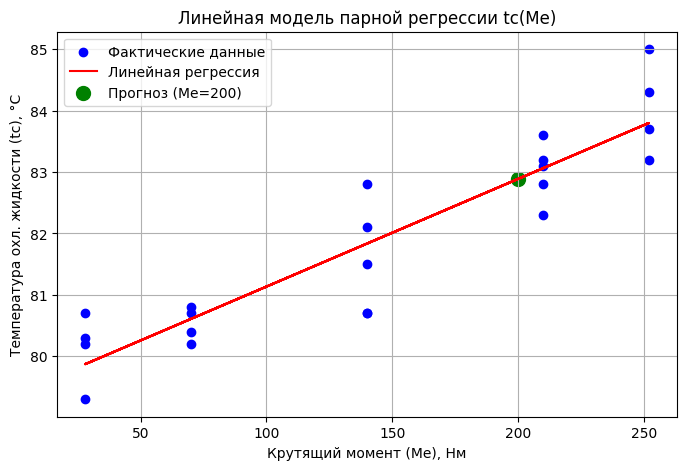

In [12]:
# Statsmodels
X_sm = sm.add_constant(X_data)
model_sm = sm.OLS(Y_data, X_sm).fit()

# Вывод полной таблицы
print(model_sm.summary())

forecast_sm = model_sm.predict([1, Me_forecast]) # также Me = 200 Нм
print(f"\nТочечный прогноз (Statsmodels) при Me={Me_forecast}: {forecast_sm[0]:.2f}")

# Визуализация
plt.figure(figsize=(8, 5))
plt.scatter(X_data, Y_data, color='blue', label='Фактические данные')
plt.plot(X_data, intercept + slope * X_data, color='red', label='Линейная регрессия')
plt.scatter([Me_forecast], [tc_forecast], color='green', s=100, label=f'Прогноз (Me={Me_forecast})')
plt.title('Линейная модель парной регрессии tc(Me)')
plt.xlabel('Крутящий момент (Me), Нм')
plt.ylabel('Температура охл. жидкости (tc), °C')
plt.legend()
plt.grid(True)
plt.show()